# PEAK M-ATH — Punycode-encoded International Domain Names

**Ref:** M21 — Punycode-encoded International Domain Names

Detect `xn--` prefixed domains in DNS queries that may masquerade as legitimate services for credential harvesting and malware delivery, following the **PEAK** framework: **Prepare → Execute → Act → Knowledge**.

**M-ATH approach:** Rule-based IDN security analysis (TR39 confusables, skeleton, mixed-script, BiDi, IDNA validity) combined with multi-signal DNS scoring, VirusTotal enrichment, and prevalence analysis.

## How to use
1. Put DNS CSV files into `input/` (e.g. event.dns.request or equivalent)
2. Run all cells
3. Review punycode findings in `output/`

pass  # Placeholder (removed environment-specific output)

In [3]:
# Scenario mode: anchor paths to this notebook's scenario folder.
import os
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    while cur != cur.parent:
        if (cur / 'detection_logics').exists() and (cur / 'scenarios').exists():
            return cur
        cur = cur.parent
    raise RuntimeError('Unable to locate repository root from current working directory.')

REPO_ROOT = find_repo_root(Path.cwd())
SCENARIO_DIR = REPO_ROOT / 'scenarios' / 'punycode_encoded_international_domain_names'
if not SCENARIO_DIR.exists():
    raise FileNotFoundError(f'Scenario folder not found: {SCENARIO_DIR.relative_to(REPO_ROOT)}')

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)  # keep imports stable

INPUT_DIR = SCENARIO_DIR / 'input'
OUTPUT_DIR = SCENARIO_DIR / 'output'
EXCLUSIONS_DIR = SCENARIO_DIR / 'exclusions'
REPO_EXCLUSIONS_DIR = REPO_ROOT / 'exclusions'
CONFIG_DIR = REPO_ROOT / 'config'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SCENARIO_MODE = True
print(f'Scenario folder: {SCENARIO_DIR.relative_to(REPO_ROOT)}')

Scenario folder: scenarios\punycode_encoded_international_domain_names


In [4]:
import glob
import time
import math
import re
import json
import ipaddress
import base64
from pathlib import Path
from urllib.parse import urlparse
from urllib.request import Request, urlopen
from urllib.error import HTTPError, URLError

import pandas as pd

from detection_logics import apply_dns_logics
from detection_logics import dns_suspicious_string
from detection_logics.idn_security_analysis import (
    analyze_idn_domain,
    normalize_idn_dashes_for_decode,
    score_idn_security_signals,
)

pd.set_option('display.max_colwidth', 180)

if not globals().get('SCENARIO_MODE', False):
    INPUT_DIR = Path('input')
    OUTPUT_DIR = Path('output')
    EXCLUSIONS_DIR = Path('exclusions')
    CONFIG_DIR = Path('../../config')
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDED_VALUES_FILE = EXCLUSIONS_DIR / 'excluded_values.conf'
EXCLUDED_VALUE_REASONS_FILE = EXCLUSIONS_DIR / 'excluded_values+reasons.conf'
EXCLUDED_PARENT_DOMAINS_FILE = EXCLUSIONS_DIR / 'excluded_parent_domains.conf'
REVIEWED_PARENT_DOMAINS_FILE = REPO_EXCLUSIONS_DIR / 'reviewed_parent_domains.conf'

RISKY_TLDS = {
    # File-extension look-alikes (confuse users into clicking)
    'zip', 'mov', 'exe', 'doc', 'app',
    # Free / near-free ccTLDs historically abused at scale
    'tk', 'gq', 'cf', 'ga', 'ml', 'pw', 'su', 'cc', 'ws',
    # High-abuse new gTLDs (Spamhaus, SURBL, Interisle reports)
    'top', 'xyz', 'icu', 'buzz', 'cyou', 'cfd', 'sbs',
    'click', 'link', 'surf', 'fun', 'vip', 'monster',
    'bond', 'quest', 'cam', 'beauty', 'hair', 'makeup', 'skin',
    'autos', 'boats',
    # Legacy gTLDs with persistently high abuse ratios
    'info', 'biz',
    # Thematic gTLDs frequently seen in phishing / scam campaigns
    'work', 'support', 'rest', 'country', 'stream', 'xin',
    'loan', 'racing', 'review', 'win', 'bid', 'download',
    'trade', 'date', 'faith', 'party', 'cricket', 'science',
    'accountant', 'men',
}

def load_conf_set(conf_path: Path) -> set:
    """Load a .conf file (one entry per line, # comments) into a lowercase set."""
    entries = set()
    with open(conf_path, encoding='utf-8') as fh:
        for line in fh:
            line = line.strip()
            if line and not line.startswith('#'):
                entries.add(line.lower())
    return entries


def _rel(p):
    try:
        if globals().get('SCENARIO_MODE', False) and 'REPO_ROOT' in globals():
            root = globals()['REPO_ROOT']
            if hasattr(p, 'is_relative_to') and p.is_relative_to(root):
                return p.relative_to(root)
        return p
    except (ValueError, AttributeError):
        return p
print(f'Input folder: {_rel(INPUT_DIR)}')
print(f'Output folder: {_rel(OUTPUT_DIR)}')
print(f'Exclusions file (values): {_rel(EXCLUDED_VALUES_FILE)}')
print(f'Exclusions file (parent domains): {_rel(EXCLUDED_PARENT_DOMAINS_FILE)}')
print(f'Reviewed parent domains file: {_rel(REVIEWED_PARENT_DOMAINS_FILE)}')
print('Detection logic enabled: dns_suspicious_string, idn_security_analysis (TR39 / UTS #46)')

ModuleNotFoundError: No module named 'pandas'

## Punycode decode helper

TR39 / IDN checks in this notebook mirror common **domain security analysis** signals: [Unicode TR39](https://www.unicode.org/reports/tr39) visual confusables (full mapping in `detection_logics/resources/unicode_TR39_confusables.txt`), Unicode **skeleton** via repeated confusable mapping, **mixed-script** letters, **BiDi** (strong RTL), **UTS #46 / IDNA** validity, and whether the **registrable TLD** label is punycode (`xn--`). The same class of checks is described in tools such as [PunycodeConverter.com](https://www.punycodeconverter.com/).

**Decode:** non-ASCII dash confusables in the hostname are normalized to HYPHEN-MINUS before punycode decoding so logs that preserve Unicode (e.g. spoofed `xn–` vs `xn--`) are handled consistently with the TR39 database.

In [4]:
def normalize_domain(value: str) -> str:
    value = (value or '').strip().lower().rstrip('.')
    value = re.sub(r'\s+', '', value)
    return value


def decode_punycode_domain(value: str) -> str:
    domain = normalize_domain(value)
    domain = normalize_idn_dashes_for_decode(domain)
    if not domain or 'xn--' not in domain:
        return ''
    decoded_labels = []
    changed = False
    for label in domain.split('.'):
        if label.startswith('xn--'):
            try:
                decoded_label = label.encode('ascii').decode('idna')
            except Exception:
                try:
                    decoded_label = label[4:].encode('ascii').decode('punycode')
                except Exception:
                    decoded_label = label
            decoded_labels.append(decoded_label)
            changed = changed or decoded_label != label
        else:
            decoded_labels.append(label)
    decoded_domain = '.'.join(decoded_labels)
    return decoded_domain if changed and decoded_domain != domain else ''

## DNS risk scoring and exclusions

Same scoring logic as `dns_url_anomaly_analysis`: `score_dns()` (length, entropy, subdomains, risky TLD, DGA-like patterns) + `apply_dns_logics()`. **IDN / TR39** signals from `idn_security_analysis` (confusables, skeleton, mixed-script, BiDi, IDNA, punycode TLD) add score in the decode-and-score cell. **Prevalence**: if input has a `count`, `prevalence`, `frequency` or similar column, low prevalence (≤2) adds +1 score. Exclusions from `exclusions/` are applied: exact values, value+reason pairs, and **parent-domain suffixes** (any domain ending with a listed parent domain is excluded).

In [5]:
def shannon_entropy(text: str) -> float:
    text = (text or '').strip()
    if not text:
        return 0.0
    probs = [text.count(ch) / len(text) for ch in set(text)]
    return -sum(p * math.log2(p) for p in probs)


def looks_like_domain(value: str) -> bool:
    if not value or not isinstance(value, str):
        return False
    value = value.strip().lower()
    if value.startswith(('http://', 'https://')):
        return False
    domain_regex = r'^(?:[a-z0-9](?:[a-z0-9-]{0,61}[a-z0-9])?\.)+[a-z]{2,63}$'
    return bool(re.match(domain_regex, value))


def score_dns(domain: str):
    """Same risk scoring as dns_url_anomaly_analysis."""
    d = normalize_domain(domain)
    reasons = []
    score = 0

    if not looks_like_domain(d):
        return 0, ['not-domain']

    labels = d.split('.')
    joined = ''.join(labels)
    entropy = shannon_entropy(joined)

    if len(d) > 55:
        score += 2
        reasons.append('very-long-domain')
    elif len(d) > 40:
        score += 1
        reasons.append('long-domain')

    if len(labels) >= 5:
        score += 1
        reasons.append('many-subdomains')

    max_label_len = max(len(x) for x in labels)
    if max_label_len > 25:
        score += 1
        reasons.append('long-label')

    if entropy > 4.0:
        score += 2
        reasons.append('high-entropy')
    elif entropy > 3.6:
        score += 1
        reasons.append('medium-entropy')

    if 'xn--' in d:
        score += 1
        reasons.append('punycode')

    if '--' in d:
        score += 1
        reasons.append('double-hyphen')

    if labels[-1] in RISKY_TLDS:
        score += 1
        reasons.append('risky-tld')

    if re.search(r'[a-z]{8,}\d{3,}|\d{5,}[a-z]{4,}', joined):
        score += 2
        reasons.append('dga-like-pattern')

    return score, reasons


LOW_PREVALENCE_THRESHOLD = 2  # count <= this → low-prevalence (rare domain, +1 score)


def score_prevalence(prevalence_value) -> tuple[int, list[str]]:
    """Apply prevalence logic when count/prevalence column exists. Low prevalence = +1 score."""
    if prevalence_value is None:
        return 0, []
    try:
        val = int(float(prevalence_value))
    except (TypeError, ValueError):
        return 0, []
    if val <= LOW_PREVALENCE_THRESHOLD:
        return 1, ['low-prevalence']
    return 0, []

def is_ip(value: str) -> bool:
    try:
        ipaddress.ip_address(value)
        return True
    except Exception:
        return False


def encode_url_id(raw_url: str) -> str:
    encoded = base64.urlsafe_b64encode(raw_url.encode('utf-8')).decode('ascii')
    return encoded.rstrip('=')


def coerce_to_url(value: str) -> str:
    if value.startswith(('http://', 'https://')):
        return value
    return f'http://{value}'


VT_MAX_RETRIES = 3
VT_RETRY_BACKOFF_BASE_SECONDS = 1.5
VT_RETRY_BACKOFF_MAX_SECONDS = 20.0


def _vt_backoff_seconds(attempt: int) -> float:
    return min(VT_RETRY_BACKOFF_MAX_SECONDS, VT_RETRY_BACKOFF_BASE_SECONDS * (2 ** max(0, attempt - 1)))


def _vt_retry_after_seconds(ex: HTTPError) -> float | None:
    retry_after = ex.headers.get('Retry-After')
    if not retry_after:
        return None
    try:
        parsed = float(str(retry_after).strip())
    except (TypeError, ValueError):
        return None
    return parsed if parsed > 0 else None


def get_vt_stats(api_key: str, value: str) -> tuple[str | None, dict | None, list, str]:
    """Returns (status, last_analysis_stats, tags, registrar)."""
    normalized = str(value or '').strip()
    if not normalized:
        return None, None, [], ''

    if is_ip(normalized):
        endpoint = f'/ip_addresses/{normalized}'
    else:
        parsed = urlparse(coerce_to_url(normalized))
        is_explicit_url = normalized.startswith(('http://', 'https://'))
        if parsed.path not in {'', '/'} or parsed.query or is_explicit_url:
            candidate_url = normalized if is_explicit_url else coerce_to_url(normalized)
            endpoint = f'/urls/{encode_url_id(candidate_url)}'
        elif looks_like_domain(parsed.hostname or normalized):
            endpoint = f'/domains/{(parsed.hostname or normalized).lower()}'
        else:
            return None, None, [], ''

    req = Request(
        f'https://www.virustotal.com/api/v3{endpoint}',
        headers={'x-apikey': api_key}
    )
    payload = {}
    for attempt in range(1, VT_MAX_RETRIES + 1):
        try:
            with urlopen(req, timeout=30) as resp:
                payload = json.loads(resp.read().decode('utf-8'))
            break
        except HTTPError as ex:
            if ex.code == 404:
                return 'not_found', {}, [], ''
            if ex.code == 429:
                if attempt < VT_MAX_RETRIES:
                    delay = _vt_retry_after_seconds(ex) or _vt_backoff_seconds(attempt)
                    time.sleep(delay)
                    continue
                return 'rate_limited', {}, [], ''
            if ex.code in {500, 502, 503, 504} and attempt < VT_MAX_RETRIES:
                time.sleep(_vt_backoff_seconds(attempt))
                continue
            raise RuntimeError(f'VirusTotal HTTP error: {ex.code}')
        except URLError as ex:
            if attempt < VT_MAX_RETRIES:
                time.sleep(_vt_backoff_seconds(attempt))
                continue
            raise RuntimeError(f'VirusTotal network error: {ex.reason}')

    attrs = payload.get('data', {}).get('attributes', {})
    stats = attrs.get('last_analysis_stats', {})
    tags = attrs.get('tags', []) or []
    if not isinstance(tags, list):
        tags = []
    registrar = str(attrs.get('registrar', '') or '').strip()
    return 'ok', stats, tags, registrar


def classify_verdict(stats: dict) -> str:
    malicious = int(stats.get('malicious', 0) or 0)
    suspicious = int(stats.get('suspicious', 0) or 0)
    harmless = int(stats.get('harmless', 0) or 0)
    undetected = int(stats.get('undetected', 0) or 0)

    if malicious > 0:
        return 'malicious'
    if suspicious > 0:
        return 'suspicious'
    if harmless > 0 and malicious == 0 and suspicious == 0:
        return 'clean'
    if undetected > 0:
        return 'undetected'
    return 'unknown'


def _parse_env_file(env_path: Path) -> dict:
    data = {}
    if not env_path.exists():
        return data
    with env_path.open('r', encoding='utf-8') as handle:
        for raw in handle:
            line = raw.strip()
            if not line or line.startswith('#') or '=' not in line:
                continue
            key, value = line.split('=', 1)
            key = key.strip()
            value = value.strip().strip('\"').strip("'")
            if key:
                data[key] = value
    return data


def resolve_vt_api_key() -> tuple[str, str]:
    env_path = SCENARIO_DIR / '.env'
    if env_path.exists():
        env_data = _parse_env_file(env_path)
        key = str(env_data.get('VT_API_KEY', '') or '').strip()
        if key:
            return key, 'scenario .env'
    key = str(os.environ.get('VT_API_KEY', '') or '').strip()
    if key:
        return key, 'environment'
    return '', 'missing'


def normalize_exclusion_value(value):
    return str(value or '').strip().lower()


def read_conf_lines(path: Path):
    if not path.exists():
        return []
    lines = []
    with path.open('r', encoding='utf-8') as handle:
        for raw in handle:
            line = raw.split('#', 1)[0].strip()
            if not line:
                continue
            lines.append(line)
    return lines


def load_exclusions_from_files(values_file: Path, value_reason_file: Path):
    excluded_values = {
        normalize_exclusion_value(v)
        for v in read_conf_lines(values_file)
        if normalize_exclusion_value(v)
    }
    excluded_pairs = set()
    for line in read_conf_lines(value_reason_file):
        if '||' not in line:
            continue
        value_part, reason_part = line.split('||', 1)
        v_norm = normalize_exclusion_value(value_part)
        r_norm = str(reason_part or '').strip().lower()
        if v_norm and r_norm:
            excluded_pairs.add((v_norm, r_norm))
    return excluded_values, excluded_pairs


def load_excluded_parent_domains(parent_domains_file: Path):
    """Load parent domain exclusions with robust matching.
    Returns tuple of normalized parent domain suffixes (with leading dot).
    """
    entries = tuple(
        normalize_exclusion_value(v)
        for v in read_conf_lines(parent_domains_file)
        if normalize_exclusion_value(v)
    )
    return entries


def matches_parent_domain_suffix(domain: str, parent_domains: tuple[str, ...]) -> bool:
    """Check if domain matches any parent domain suffix (robust matching).
    Handles cases like:
    - domain='xn--pharma.aventis.com', parent='aventis.com' → True
    - domain='pharma.aventis.com', parent='aventis.com' → True
    - domain='aventis.com', parent='aventis.com' → True
    """
    domain_norm = normalize_exclusion_value(domain)
    
    for parent in parent_domains:
        parent_norm = normalize_exclusion_value(parent)
        # Exact match (entire domain is the parent)
        if domain_norm == parent_norm:
            return True
        # Suffix match (domain ends with .parent)
        if domain_norm.endswith(f'.{parent_norm}'):
            return True
    
    return False


def is_excluded(value, reasons, excluded_values, excluded_pairs, excluded_parent_suffixes=()):
    value_norm = normalize_exclusion_value(value)
    
    # Check exact value match
    if value_norm in excluded_values:
        return True
    
    # Check parent domain suffix match (improved logic)
    if excluded_parent_suffixes:
        if matches_parent_domain_suffix(value, excluded_parent_suffixes):
            return True
    
    # Check value+reason pair match
    reason_list = [str(r or '').strip().lower() for r in reasons]
    for reason in reason_list:
        if (value_norm, reason) in excluded_pairs:
            return True
    
    return False


excluded_values_cfg, excluded_value_reason_cfg = load_exclusions_from_files(
    EXCLUDED_VALUES_FILE,
    EXCLUDED_VALUE_REASONS_FILE
)

excluded_parent_domains_cfg = load_excluded_parent_domains(EXCLUDED_PARENT_DOMAINS_FILE)

reviewed_parent_domains_cfg = {
    normalize_exclusion_value(v)
    for v in read_conf_lines(REVIEWED_PARENT_DOMAINS_FILE)
    if normalize_exclusion_value(v)
}

print(f'Exclusion files loaded: values={len(excluded_values_cfg)}, value+reason={len(excluded_value_reason_cfg)}, parent-domains={len(excluded_parent_domains_cfg)}')
print(f'Reviewed parent domains (kept in findings): {len(reviewed_parent_domains_cfg)}')

Exclusion files loaded: values=25, value+reason=0, parent-domains=10
Reviewed parent domains (kept in findings): 0


## Load DNS data

In [6]:

csv_paths = sorted(glob.glob(str(INPUT_DIR / '**' / '*.csv'), recursive=True))
print(f'Found {len(csv_paths)} CSV file(s).')

if not csv_paths:
    raise FileNotFoundError(f'No CSV files in {_rel(INPUT_DIR)}. Add DNS logs with event.dns.request or equivalent.')

dfs = []
for p in csv_paths:
    df = pd.read_csv(p)
    try:
        src_rel = str(Path(p).relative_to(REPO_ROOT)) if 'REPO_ROOT' in globals() and Path(p).is_relative_to(REPO_ROOT) else p
    except (ValueError, AttributeError):
        src_rel = p
    df['_source_file'] = src_rel
    dfs.append(df)
raw = pd.concat(dfs, ignore_index=True)

domain_col = next((c for c in raw.columns if 'dns.request' in c.lower() or c in ('query', 'domain')), None)
if not domain_col:
    raise ValueError(f'No DNS request column found. Columns: {list(raw.columns)}')

PREVALENCE_COL_HINTS = ['count', 'prevalence', 'frequency', 'occurrences', 'event_count', 'num_events', 'hits', 'seen']
prevalence_col = next(
    (c for c in raw.columns
     if c.lower() in PREVALENCE_COL_HINTS or any(h in c.lower() for h in PREVALENCE_COL_HINTS)),
    None
)

VT_SLEEP_SECONDS = 0.2
# Number of parallel VT workers. Increase for premium API keys (higher rate limits).
# Free tier: 4 req/min → keep VT_MAX_WORKERS=1. Standard/premium: safe up to 10+.
VT_MAX_WORKERS = 8

SUSPICIOUS_REGISTRARS = load_conf_set(CONFIG_DIR / 'suspicious_registrars.conf')

raw['domain'] = raw[domain_col].astype(str).str.strip().str.lower().str.rstrip('.')
raw = raw[raw['domain'].str.len() > 0]
punycode_only = raw[raw['domain'].str.contains('xn--', na=False)].copy()

domain_vt_verdict = {}
domain_vt_tags = {}
domain_vt_registrar = {}
domain_vt_lookup_status = {}
if not punycode_only.empty:
    from concurrent.futures import ThreadPoolExecutor, as_completed

    vt_api_key, vt_key_source = resolve_vt_api_key()
    if not vt_api_key:
        raise RuntimeError('VT_API_KEY is required. Set it in scenario .env or OS environment variable.')

    unique_domains = sorted(set(punycode_only['domain'].astype(str).tolist()))
    print(f'Querying VirusTotal for {len(unique_domains)} unique punycode domain(s) '
          f'({VT_MAX_WORKERS} parallel worker(s), {VT_SLEEP_SECONDS}s delay/worker)...')

    def _query_vt(domain):
        tags = []
        registrar = ''
        vt_lookup_status = 'lookup_failed'
        try:
            status, stats, tags, registrar = get_vt_stats(vt_api_key, domain)
            if status == 'ok':
                vt_lookup_status = 'ok'
                verdict = classify_verdict(stats)
            elif status == 'not_found':
                vt_lookup_status = 'not_found'
                verdict = 'not_found'
            elif status == 'rate_limited':
                vt_lookup_status = 'rate_limited'
                verdict = ''
            elif status is None:
                vt_lookup_status = 'invalid_input'
                verdict = ''
            else:
                vt_lookup_status = 'error'
                verdict = ''
        except Exception:
            verdict = ''
            vt_lookup_status = 'lookup_failed'
        if VT_SLEEP_SECONDS > 0:
            time.sleep(VT_SLEEP_SECONDS)
        return domain, verdict, tags, registrar, vt_lookup_status

    with ThreadPoolExecutor(max_workers=VT_MAX_WORKERS) as executor:
        futures = {executor.submit(_query_vt, d): d for d in unique_domains}
        for future in as_completed(futures):
            d, verdict, tags, registrar, vt_lookup_status = future.result()
            if verdict:
                domain_vt_verdict[d] = verdict
            if tags:
                domain_vt_tags[d] = [str(t).strip().lower() for t in tags if str(t).strip()]
            if registrar:
                domain_vt_registrar[d] = registrar
            domain_vt_lookup_status[d] = vt_lookup_status
    print('VirusTotal enrichment complete.')

domain_prevalence = {}
if prevalence_col:
    prevalence_numeric = pd.to_numeric(punycode_only[prevalence_col], errors='coerce')
    if prevalence_numeric.notna().any():
        punycode_only['_prevalence_numeric'] = prevalence_numeric
        domain_prevalence = (
            punycode_only.groupby('domain')['_prevalence_numeric']
            .sum(min_count=1)
            .fillna(0)
            .to_dict()
        )
        print(f'Prevalence column detected: {prevalence_col}')
    else:
        print(f'Prevalence column detected but non-numeric: {prevalence_col}; falling back to observed counts.')

if not domain_prevalence:
    domain_prevalence = punycode_only.groupby('domain').size().astype(int).to_dict()
    print('Prevalence fallback: using observed domain counts from input rows.')

print(f'Domains with VT verdict from API: {sum(1 for v in domain_vt_verdict.values() if v)}')
if domain_vt_lookup_status:
    print('VT lookup status counts:', pd.Series(domain_vt_lookup_status.values()).value_counts().to_dict())

print(f'Loaded {len(raw):,} DNS records. {len(punycode_only):,} contain xn-- (punycode).')


Found 5 CSV file(s).
Querying VirusTotal for 2421 unique punycode domain(s) (8 parallel worker(s), 0.2s delay/worker)...
VirusTotal enrichment complete.
Prevalence column detected: src.process.dnsCount
Domains with VT verdict from API: 0
VT lookup status counts: {'lookup_failed': 1634, 'invalid_input': 787}
Loaded 8,742 DNS records. 8,742 contain xn-- (punycode).


## Decode and score punycode domains

In [7]:
findings = []
seen = set()
excluded_count = 0

for idx, row in punycode_only.iterrows():
    domain = row['domain']
    if domain in seen:
        continue
    seen.add(domain)
    decoded = decode_punycode_domain(domain)
    idn_report = analyze_idn_domain(domain, decoded if decoded else '')

    score, reasons = score_dns(domain)
    d_idn, r_idn = score_idn_security_signals(idn_report)
    score += d_idn
    reasons.extend(r_idn)
    decoded_for_logic = f'punycode:{decoded}' if decoded else 'punycode:'
    vt_verdict = str(domain_vt_verdict.get(domain, '') or '').strip().lower()
    if vt_verdict:
        decoded_for_logic = f'{decoded_for_logic}|vt:{vt_verdict}'

    delta, logic_reasons = apply_dns_logics(domain, decoded_for_logic)
    score += delta
    reasons.extend(logic_reasons)

    # Ensure dns_suspicious_string is applied even if logic registry changes.
    if 'dns_suspicious_string' not in logic_reasons:
        extra_delta, extra_reason = dns_suspicious_string.apply(domain, decoded_for_logic)
        if extra_delta > 0 and extra_reason:
            score += extra_delta
            reasons.append(extra_reason)

    prevalence_val = domain_prevalence.get(domain) if domain_prevalence else None
    delta_prev, prev_reasons = score_prevalence(prevalence_val)
    score += delta_prev
    reasons.extend(prev_reasons)

    vt_tags_list = domain_vt_tags.get(domain, []) or []
    for tag in vt_tags_list:
        score += 1
        reasons.append(f'vt-tag:{tag}')
    vt_tags_str = ','.join(vt_tags_list) if vt_tags_list else ''

    registrar = str(domain_vt_registrar.get(domain, '') or '').strip()
    if registrar and registrar.lower() in SUSPICIOUS_REGISTRARS:
        score += 2
        reasons.append('suspicious-registrar')

    if score >= 2:
        # Use improved parent domain exclusion check
        if is_excluded(domain, reasons, excluded_values_cfg, excluded_value_reason_cfg, excluded_parent_domains_cfg):
            excluded_count += 1
            continue
        rec = {
            'domain': domain,
            'decoded': decoded if decoded else '',
            'homograph_risk': idn_report['homograph_risk'],
            'unicode_skeleton': idn_report['unicode_skeleton'],
            'tr39_confusable_count': idn_report['tr39_confusable_count'],
            'tr39_confusable_detail': idn_report['tr39_confusable_detail'],
            'mixed_script': idn_report['mixed_script'],
            'mixed_script_list': idn_report['mixed_script_list'],
            'bidi_rtl': idn_report['bidi_rtl'],
            'idn_punycode_tld': idn_report['idn_punycode_tld'],
            'idna_valid': idn_report['idna_valid'],
            'idna_errors': idn_report['idna_errors'],
            'vt_verdict': vt_verdict if vt_verdict else '',
            'vt_lookup_status': str(domain_vt_lookup_status.get(domain, '') or ''),
            'vt_tags': vt_tags_str,
            'vt_registrar': registrar,
            'score': score,
            'reasons': ','.join(reasons),
            'source_file': row.get('_source_file', '')
        }
        rec['prevalence'] = max(1, int(float(prevalence_val))) if prevalence_val is not None else 1
        findings.append(rec)

findings_df = pd.DataFrame(findings)
if len(findings_df) > 0:
    findings_df = findings_df.sort_values('score', ascending=False).reset_index(drop=True)
    print(f'Excluded records: {excluded_count}')
    print(f'Found {len(findings_df):,} unique punycode domains (score >= 2).')
    display(findings_df.head(20))
else:
    print(f'Excluded records: {excluded_count}')
    print('No punycode domains to report.')

Excluded records: 102
Found 2,319 unique punycode domains (score >= 2).


,domain,decoded,homograph_risk,unicode_skeleton,tr39_confusable_count,tr39_confusable_detail,mixed_script,mixed_script_list,bidi_rtl,idn_punycode_tld,idna_valid,idna_errors,vt_verdict,vt_lookup_status,vt_tags,vt_registrar,score,reasons,source_file,prevalence
0,xn--9natb9hpd983r4ahence3e6h0b.xn----91a3ab6kzds46t8aiepce9esi3b.xn----91a3ab6kzds46t8aiepce9esi3b.fatfreecooking.com,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.fatfreecooking.com,high,ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ.ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ-.ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ-.fatfreecooking.corn,7,U+028F:y;U+1D0D:ʍ;U+1D04:c;U+026A:i;U+006D:rn;U+0030:O;U+0031:l,False,Latin,False,False,False,leading-or-trailing-hyphen;leading-or-trailing-hyphen;Label must not start or end with a hyphen,,lookup_failed,,,16,"very-long-domain,many-subdomains,long-label,high-entropy,punycode,double-hyphen,tr39-visual-confusable,idna-uts46-invalid,dns_suspicious_string,low-prevalence",scenarios\punycode_encoded_international_domain_names\input\power-query-results_2026-02-24T14_41_27Z.csv,1
1,xn--9natb9hpd983r4ahence3e6h0b.xn----91a3ab6kzds46t8aiepce9esi3b.xn----91a3ab6kzds46t8aiepce9esi3b.teleconect.com,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.teleconect.com,high,ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ.ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ-.ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ-.teleconect.corn,7,U+028F:y;U+1D0D:ʍ;U+1D04:c;U+026A:i;U+006D:rn;U+0030:O;U+0031:l,False,Latin,False,False,False,leading-or-trailing-hyphen;leading-or-trailing-hyphen;Label must not start or end with a hyphen,,lookup_failed,,,16,"very-long-domain,many-subdomains,long-label,high-entropy,punycode,double-hyphen,tr39-visual-confusable,idna-uts46-invalid,dns_suspicious_string,low-prevalence",scenarios\punycode_encoded_international_domain_names\input\power-query-results_2026-02-24T14_41_27Z.csv,1
2,xn--9natb9hpd983r4ahence3e6h0b.xn----91a3ab6kzds46t8aiepce9esi3b.cayiqoragiripe.com,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.cayiqoragiripe.com,high,ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ.ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ-.cayiqoragiripe.corn,7,U+028F:y;U+1D0D:ʍ;U+1D04:c;U+026A:i;U+006D:rn;U+0030:O;U+0031:l,False,Latin,False,False,False,leading-or-trailing-hyphen;Label must not start or end with a hyphen,,lookup_failed,,,15,"very-long-domain,long-label,high-entropy,punycode,double-hyphen,tr39-visual-confusable,idna-uts46-invalid,dns_suspicious_string,low-prevalence",scenarios\punycode_encoded_international_domain_names\input\power-query-results_2026-03-13T16_00_41Z.csv,1
3,xn----91a3ab6kzds46t8aiepce9esi3b.clubsandsocieties.info,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.clubsandsocieties.info,high,ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ-.clubsandsocieties.info,5,U+028F:y;U+1D0D:ʍ;U+1D04:c;U+026A:i;U+0031:l,False,Latin,False,False,False,leading-or-trailing-hyphen;Label must not start or end with a hyphen,,lookup_failed,,,15,"very-long-domain,long-label,high-entropy,punycode,double-hyphen,risky-tld,tr39-visual-confusable,idna-uts46-invalid,dns_suspicious_string,low-prevalence",scenarios\punycode_encoded_international_domain_names\input\power-query-results_2026-03-13T16_00_41Z.csv,1
4,xn--9natb9hpd983r4ahence3e6h0b.xn----91a3ab6kzds46t8aiepce9esi3b.xn----91a3ab6kzds46t8aiepce9esi3b.countrypeddlershop.com,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.countrypeddlershop.com,high,ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ.ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ-.ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ-.countrypeddlershop.corn,7,U+028F:y;U+1D0D:ʍ;U+1D04:c;U+026A:i;U+006D:rn;U+0030:O;U+0031:l,False,Latin,False,False,False,leading-or-trailing-hyphen;leading-or-trailing-hyphen;Label must not start or end with a hyphen,,lookup_failed,,,15,"very-long-domain,many-subdomains,long-label,high-entropy,punycode,double-hyphen,tr39-visual-confusable,idna-uts46-invalid,dns_suspicious_string",scenarios\punycode_encoded_international_domain_names\input\power-query-results_2026-02-24T14_41_27Z.csv,7456
5,xn--9natb9hpd983r4ahence3e6h0b.xn----91a3ab6kzds46t8aiepce9esi3b.xn----91a3ab6kzds46t8aiepce9esi3b.retiremaverick.com,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.retiremaverick.com,high,ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ.ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ-.ᴘᴀyʍᴇɴᴛᴅᴇcʟiɴᴇᴅ-.retirernaverick.corn,7,U+028F:y;U+1D0D:ʍ;U+1D04:c;U+026A:i;U+006D:rn;U+0

In [8]:
out_path = OUTPUT_DIR / 'punycode_idn_results.csv'
top100_out_path = OUTPUT_DIR / 'punycode_idn_top100.csv'
OUTPUT_COLUMNS = [
    'domain', 'decoded', 'homograph_risk', 'unicode_skeleton', 'tr39_confusable_count',
    'tr39_confusable_detail', 'mixed_script', 'mixed_script_list', 'bidi_rtl', 'idn_punycode_tld',
    'idna_valid', 'idna_errors', 'vt_verdict', 'vt_lookup_status', 'vt_tags', 'vt_registrar', 'score', 'reasons', 'source_file', 'prevalence',
]
TOP100_OUTPUT_COLUMNS = [
    'Full domain (Punycode)',
    'Full domain (Unicode)',
    'Suspicious punycode',
    'Suspicious unicode version of the suspicious punycode string',
]

def decode_punycode_label(label: str) -> str:
    normalized_label = normalize_domain(label)
    normalized_label = normalize_idn_dashes_for_decode(normalized_label)
    if not normalized_label.startswith('xn--'):
        return ''
    try:
        return normalized_label.encode('ascii').decode('idna')
    except Exception:
        try:
            return normalized_label[4:].encode('ascii').decode('punycode')
        except Exception:
            return ''


def extract_suspicious_matches(domain: str, decoded_domain: str) -> tuple[list[str], list[str]]:
    normalized_domain = normalize_domain(domain)
    normalized_decoded_domain = str(decoded_domain or '').strip()
    punycode_matches: list[str] = []
    unicode_matches: list[str] = []

    for candidate in getattr(dns_suspicious_string, 'DNS_SUSPICIOUS_STRINGS', []):
        normalized_candidate = normalize_domain(candidate)
        if normalized_candidate and normalized_candidate in normalized_domain and normalized_candidate not in punycode_matches:
            punycode_matches.append(normalized_candidate)
            decoded_candidate = decode_punycode_label(normalized_candidate)
            unicode_matches.append(decoded_candidate if decoded_candidate else normalized_candidate)

    decoded_indicators = [
        str(item or '').strip()
        for item in getattr(dns_suspicious_string, 'DECODED_SUSPICIOUS_STRINGS', [])
        if str(item or '').strip()
    ]
    if decoded_indicators and normalized_decoded_domain:
        punycode_labels = [
            label for label in normalized_domain.split('.')
            if label.startswith('xn--')
        ]
        for label in punycode_labels:
            decoded_label = decode_punycode_label(label)
            if not decoded_label:
                continue
            for indicator in decoded_indicators:
                if indicator in decoded_label and label not in punycode_matches:
                    punycode_matches.append(label)
                    unicode_matches.append(decoded_label)
                    break

    return punycode_matches, unicode_matches


def build_top100_export_frame(source_df: pd.DataFrame) -> pd.DataFrame:
    ranked_df = source_df.sort_values(['score', 'domain'], ascending=[False, True]).head(100)
    records = []
    for _, row in ranked_df.iterrows():
        full_domain_punycode = str(row.get('domain', '') or '')
        full_domain_unicode = str(row.get('decoded', '') or '').strip() or full_domain_punycode
        suspicious_matches, suspicious_unicode_matches = extract_suspicious_matches(
            full_domain_punycode,
            full_domain_unicode,
        )
        records.append({
            'Full domain (Punycode)': full_domain_punycode,
            'Full domain (Unicode)': full_domain_unicode,
            'Suspicious punycode': ','.join(suspicious_matches),
            'Suspicious unicode version of the suspicious punycode string': ','.join(suspicious_unicode_matches),
        })
    return pd.DataFrame(records, columns=TOP100_OUTPUT_COLUMNS)


if len(findings_df) > 0:
    findings_df.to_csv(out_path, index=False)
    print(f'Saved to {_rel(out_path)}')
    top100_df = build_top100_export_frame(findings_df)
    top100_df.to_csv(top100_out_path, index=False)
    print(f'Saved top-100 export to {_rel(top100_out_path)}')
else:
    top100_df = pd.DataFrame(columns=TOP100_OUTPUT_COLUMNS)
    pd.DataFrame(columns=OUTPUT_COLUMNS).to_csv(out_path, index=False)
    top100_df.to_csv(top100_out_path, index=False)
    print(f'Empty results saved to {_rel(out_path)}')
    print(f'Empty top-100 export saved to {_rel(top100_out_path)}')

Saved to scenarios\punycode_encoded_international_domain_names\output\punycode_idn_results.csv
Saved top-100 export to scenarios\punycode_encoded_international_domain_names\output\punycode_idn_top100.csv


## False-positive parent-domain candidates

Domains with **no `dns_suspicious_string` hit** and **score ≤ 3** are likely false positives. This export groups them by `parent_domain` (the non-punycode suffix after the last `xn--` label) so analysts can review and bulk-add parent domains to `exclusions/excluded_parent_domains.conf`.

In [9]:
def extract_parent_domain(domain: str) -> str:
    """Return the non-punycode suffix after the last xn-- label."""
    labels = str(domain or '').strip().lower().rstrip('.').split('.')
    last_xn_idx = -1
    for i, label in enumerate(labels):
        if label.startswith('xn--'):
            last_xn_idx = i
    if last_xn_idx < 0 or last_xn_idx >= len(labels) - 1:
        return ''
    return '.'.join(labels[last_xn_idx + 1:])


FP_MAX_SCORE = 3
fp_candidates_path = OUTPUT_DIR / 'punycode_idn_false_positive_parent_domains_candidates.csv'
FP_OUTPUT_COLUMNS = OUTPUT_COLUMNS + ['parent_domain']

if len(findings_df) > 0:
    no_suspicious = ~findings_df['reasons'].fillna('').str.contains('dns_suspicious_string', regex=False)
    low_score = findings_df['score'] <= FP_MAX_SCORE
    fp_df = findings_df.loc[no_suspicious & low_score].copy()
    fp_df['parent_domain'] = fp_df['domain'].apply(extract_parent_domain)

    if reviewed_parent_domains_cfg:
        before_reviewed = len(fp_df)
        fp_df = fp_df[~fp_df['parent_domain'].str.lower().isin(reviewed_parent_domains_cfg)].reset_index(drop=True)
        reviewed_removed = before_reviewed - len(fp_df)
    else:
        reviewed_removed = 0

    fp_df = fp_df.sort_values(['score', 'parent_domain', 'domain'], ascending=True).reset_index(drop=True)
    fp_df[FP_OUTPUT_COLUMNS].to_csv(fp_candidates_path, index=False)
    print(f'False-positive candidates: {len(fp_df):,} entries (score ≤ {FP_MAX_SCORE}, no dns_suspicious_string).')
    if reviewed_removed:
        print(f'Removed {reviewed_removed:,} entries whose parent domain was already reviewed (reviewed_parent_domains.conf).')
    print(f'Unique parent domains: {fp_df["parent_domain"].nunique():,}')
    print(f'Saved to {_rel(fp_candidates_path)}')
    display(fp_df[['domain', 'decoded', 'parent_domain', 'score', 'reasons', 'vt_verdict']].head(20))
else:
    fp_df = pd.DataFrame(columns=FP_OUTPUT_COLUMNS)
    fp_df.to_csv(fp_candidates_path, index=False)
    print(f'No findings — empty false-positive candidates saved to {_rel(fp_candidates_path)}')

False-positive candidates: 321 entries (score ≤ 3, no dns_suspicious_string).
Unique parent domains: 24
Saved to scenarios\punycode_encoded_international_domain_names\output\punycode_idn_false_positive_parent_domains_candidates.csv


,domain,decoded,parent_domain,score,reasons,vt_verdict
0,xn--d2slcw3kip6qhttps-krb,d2slcw3kip6qåhttps,,2,"not-domain,idn-punycode-tld,low-prevalence",
1,xn--hthttps-n2a,hüthttps,,2,"not-domain,idn-punycode-tld,low-prevalence",
2,xn--luzsfilesrv3-r4g,luzsfi̇lesrv3,,2,"not-domain,idn-punycode-tld,low-prevalence",
3,xn--luzsfilesrv34-8nh,luzsfi̇lesrv34,,2,"not-domain,idn-punycode-tld,low-prevalence",
4,xn--brtschi-5wa.ch,bärtschi.ch,ch,2,"punycode,double-hyphen",
5,xn--tllya-xqa.cylex.hu,tállya.cylex.hu,cylex.hu,2,"punycode,double-hyphen",
6,xn--bcher-kva.de,bücher.de,de,2,"punycode,double-hyphen",
7,xn--deraktionr-y5a.de,deraktionär.de,de,2,"punycode,double-hyphen",
8,xn--gnstigbestellen-zvb.de,günstigbestellen.de,de,2,"punycode,double-hyphen",
9,xn--grn-ioaaa.de,grüüün.de,de,2,"punycode,double-hyphen",


In [10]:
print('Top-100 highest-risk punycode findings preview:')
if len(top100_df) > 0:
    display(top100_df.head(20))
else:
    display(top100_df)

Top-100 highest-risk punycode findings preview:


,Full domain (Punycode),Full domain (Unicode),Suspicious punycode,Suspicious unicode version of the suspicious punycode string
0,xn--9natb9hpd983r4ahence3e6h0b.xn----91a3ab6kzds46t8aiepce9esi3b.xn----91a3ab6kzds46t8aiepce9esi3b.fatfreecooking.com,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.fatfreecooking.com,"xn--9natb9hpd983r4ahence3e6h0b,xn----91a3ab6kzds46t8aiepce9esi3b","ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-"
1,xn--9natb9hpd983r4ahence3e6h0b.xn----91a3ab6kzds46t8aiepce9esi3b.xn----91a3ab6kzds46t8aiepce9esi3b.teleconect.com,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.teleconect.com,"xn--9natb9hpd983r4ahence3e6h0b,xn----91a3ab6kzds46t8aiepce9esi3b","ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-"
2,xn----91a3ab6kzds46t8aiepce9esi3b.clubsandsocieties.info,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.clubsandsocieties.info,xn----91a3ab6kzds46t8aiepce9esi3b,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-
3,xn--9natb9hpd983r4ahence3e6h0b.xn----91a3ab6kzds46t8aiepce9esi3b.cayiqoragiripe.com,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.cayiqoragiripe.com,"xn--9natb9hpd983r4ahence3e6h0b,xn----91a3ab6kzds46t8aiepce9esi3b","ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-"
4,xn--9natb9hpd983r4ahence3e6h0b.xn----91a3ab6kzds46t8aiepce9esi3b.xn----91a3ab6kzds46t8aiepce9esi3b.countrypeddlershop.com,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.countrypeddlershop.com,"xn--9natb9hpd983r4ahence3e6h0b,xn----91a3ab6kzds46t8aiepce9esi3b","ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-"
5,xn--9natb9hpd983r4ahence3e6h0b.xn----91a3ab6kzds46t8aiepce9esi3b.xn----91a3ab6kzds46t8aiepce9esi3b.retiremaverick.com,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.retiremaverick.com,"xn--9natb9hpd983r4ahence3e6h0b,xn----91a3ab6kzds46t8aiepce9esi3b","ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-"
6,xn---------jii1cacbcblqs7acgd8c3af2czbf7jj4srccgei6e1bo8efei.a3erf.com,بحث-حول-الغذاء-الصحي-والغير-صحي-بالفرنسية.a3erf.com,,
7,xn--------mp3-p2lcbbb1b1bj0f9awc0i2hvcfaeef0acq3amc5gn.hiatk.com,الف-تحيه-للناس-العشريه-لهشام-جمال-mp3.hiatk.com,,
8,xn----91a3ab6kzds46t8aiepce9esi3b.7ka.info,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.7ka.info,xn----91a3ab6kzds46t8aiepce9esi3b,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-
9,xn----91a3ab6kzds46t8aiepce9esi3b.niketanjun.info,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-.niketanjun.info,xn----91a3ab6kzds46t8aiepce9esi3b,ᴘᴀʏᴍᴇɴᴛᴅᴇᴄʟɪɴᴇᴅ-


## KPIs and Visualizations

Summary metrics and graphical representation of punycode detection outcomes.

In [11]:
# Key Performance Indicators
total_dns = len(raw)
total_punycode = len(punycode_only)
unique_punycode = punycode_only['domain'].nunique() if not punycode_only.empty else 0
findings_count = len(findings_df)
try:
    excluded_count_val = excluded_count
except NameError:
    excluded_count_val = 0
punycode_pct = 100 * total_punycode / total_dns if total_dns else 0
findings_rate = 100 * findings_count / unique_punycode if unique_punycode else 0
avg_score = float(findings_df['score'].mean()) if len(findings_df) > 0 else 0
max_score = int(findings_df['score'].max()) if len(findings_df) > 0 else 0
malicious_count = sum(1 for v in findings_df['vt_verdict'] if v == 'malicious') if len(findings_df) > 0 else 0
suspicious_count = sum(1 for v in findings_df['vt_verdict'] if v == 'suspicious') if len(findings_df) > 0 else 0

# Additional KPIs
low_prevalence_count = sum(1 for v in findings_df['prevalence'] if v is not None and int(v) <= LOW_PREVALENCE_THRESHOLD) if len(findings_df) > 0 else 0
vt_dga_count = sum(1 for t in findings_df['vt_tags'].fillna('') if 'dga' in str(t).lower()) if len(findings_df) > 0 else 0
risky_tld_count = sum(1 for d in findings_df['domain'] if d and d.split('.')[-1].lower() in RISKY_TLDS) if len(findings_df) > 0 else 0
vt_undetected_count = sum(1 for v in findings_df['vt_verdict'] if v in ('undetected', 'not_found', '')) if len(findings_df) > 0 else 0
total_prevalence = int(findings_df['prevalence'].sum()) if len(findings_df) > 0 and 'prevalence' in findings_df.columns else 0
dns_suspicious_count = sum(1 for r in findings_df['reasons'].fillna('') if 'dns_suspicious_string' in str(r)) if len(findings_df) > 0 else 0
unique_source_files = findings_df['source_file'].nunique() if len(findings_df) > 0 and 'source_file' in findings_df.columns else 0
tr39_confusable_findings = int((findings_df['tr39_confusable_count'] > 0).sum()) if len(findings_df) > 0 and 'tr39_confusable_count' in findings_df.columns else 0
homograph_high = int((findings_df['homograph_risk'] == 'high').sum()) if len(findings_df) > 0 and 'homograph_risk' in findings_df.columns else 0
idna_invalid_findings = int((findings_df['idna_valid'] == False).sum()) if len(findings_df) > 0 and 'idna_valid' in findings_df.columns else 0
mixed_script_findings = int(findings_df['mixed_script'].fillna(False).astype(bool).sum()) if len(findings_df) > 0 and 'mixed_script' in findings_df.columns else 0
suspicious_registrar_count = sum(1 for r in findings_df['reasons'].fillna('') if 'suspicious-registrar' in str(r)) if len(findings_df) > 0 else 0

kpi_data = [
    ('Total DNS records scanned', f'{total_dns:,}'),
    ('Punycode domains (xn--)', f'{total_punycode:,} ({punycode_pct:.2f}%)'),
    ('Unique punycode domains', f'{unique_punycode:,}'),
    ('High-risk findings (score ≥ 2)', f'{findings_count:,}'),
    ('Findings rate (of punycode)', f'{findings_rate:.1f}%'),
    ('Excluded (whitelisted)', f'{excluded_count_val:,}'),
    ('Average risk score', f'{avg_score:.2f}'),
    ('Max risk score', f'{max_score}'),
    ('VT malicious', f'{malicious_count:,}'),
    ('VT suspicious', f'{suspicious_count:,}'),
    ('Low-prevalence findings (≤2)', f'{low_prevalence_count:,}'),
    ('Findings with VT DGA tag', f'{vt_dga_count:,}'),
    ('Findings with risky TLD', f'{risky_tld_count:,}'),
    ('Suspicious registrar (findings)', f'{suspicious_registrar_count:,}'),
    ('VT undetected/not_found', f'{vt_undetected_count:,}'),
    ('Total prevalence (findings)', f'{total_prevalence:,}'),
    ('With dns_suspicious_string', f'{dns_suspicious_count:,}'),
    ('TR39 confusable hit (findings)', f'{tr39_confusable_findings:,}'),
    ('Homograph risk high', f'{homograph_high:,}'),
    ('IDNA/UTS46 invalid (findings)', f'{idna_invalid_findings:,}'),
    ('Mixed-script (findings)', f'{mixed_script_findings:,}'),
    ('Unique source files', f'{unique_source_files:,}'),
]
kpi_df = pd.DataFrame(kpi_data, columns=['KPI', 'Value'])
display(kpi_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

KPI,Value
Total DNS records scanned,"8,742"
Punycode domains (xn--),"8,742 (100.00%)"
Unique punycode domains,"2,421"
High-risk findings (score ≥ 2),"2,319"
Findings rate (of punycode),95.8%
Excluded (whitelisted),102
Average risk score,5.39
Max risk score,16
VT malicious,0
VT suspicious,0


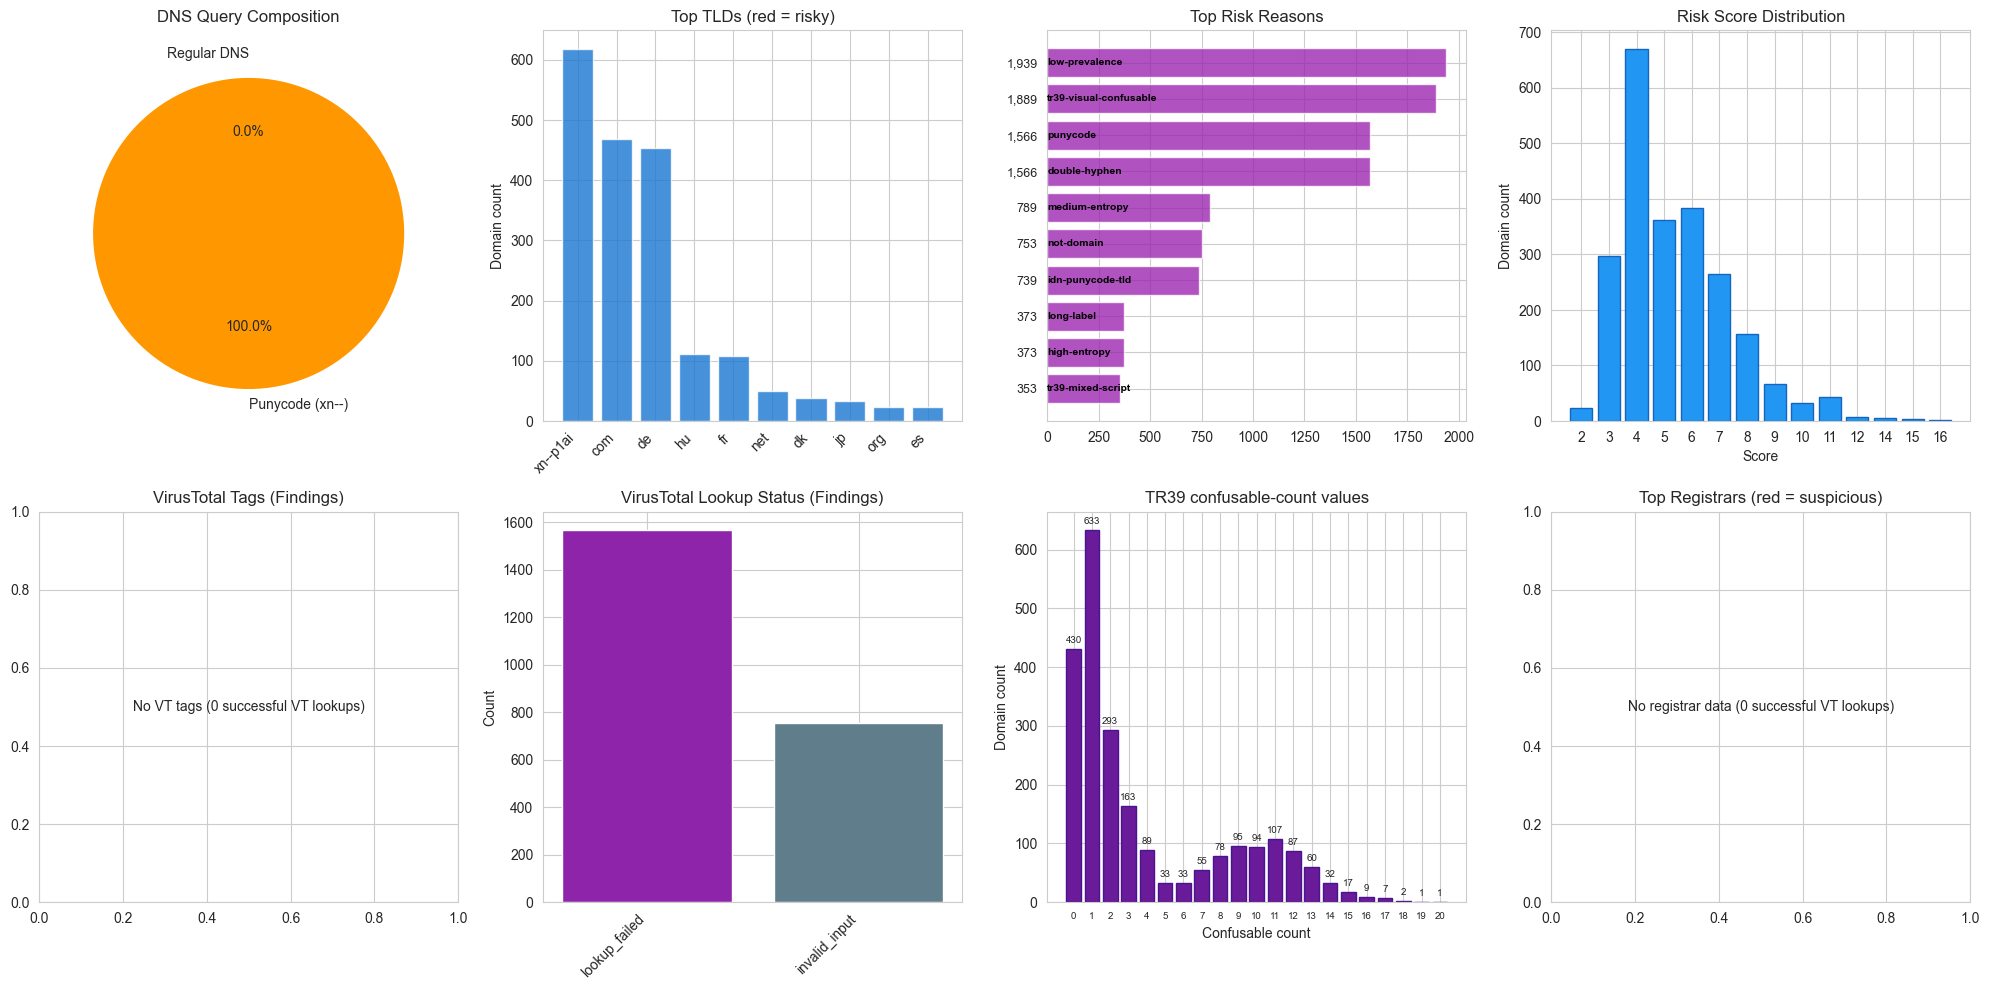

Saved chart to scenarios\punycode_encoded_international_domain_names\output\punycode_idn_kpis.png


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
fig = plt.figure(figsize=(20, 10))
grid = fig.add_gridspec(2, 4)
ax1 = fig.add_subplot(grid[0, 0])
ax2 = fig.add_subplot(grid[0, 1])
ax3 = fig.add_subplot(grid[0, 2])
ax4 = fig.add_subplot(grid[0, 3])
ax5 = fig.add_subplot(grid[1, 0])
ax6 = fig.add_subplot(grid[1, 1])
ax7 = fig.add_subplot(grid[1, 2])
ax8 = fig.add_subplot(grid[1, 3])

# 1. DNS composition: Punycode vs regular
labels = ['Regular DNS', 'Punycode (xn--)']
sizes = [total_dns - total_punycode, total_punycode]
colors = ['#4CAF50', '#FF9800']
explode = (0, 0.05) if total_punycode > 0 else (0, 0)
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, explode=explode, startangle=90)
ax1.set_title('DNS Query Composition')

# 2. TLD distribution (findings only)
if len(findings_df) > 0:
    tlds = findings_df['domain'].str.split('.').str[-1].str.lower()
    tld_counts = tlds.value_counts().head(10)
    if len(tld_counts) > 0:
        colors_tld = ['#D32F2F' if t in RISKY_TLDS else '#1976D2' for t in tld_counts.index]
        ax2.bar(tld_counts.index, tld_counts.values, color=colors_tld, alpha=0.8)
        ax2.tick_params(axis='x', labelrotation=45)
        for label in ax2.get_xticklabels():
            label.set_horizontalalignment('right')
    else:
        ax2.text(0.5, 0.5, 'No TLDs', ha='center', va='center', transform=ax2.transAxes)
else:
    ax2.text(0.5, 0.5, 'No findings', ha='center', va='center', transform=ax2.transAxes)
ax2.set_title('Top TLDs (red = risky)')
ax2.set_ylabel('Domain count')

# 3. Top risk reasons (flattened)
if len(findings_df) > 0 and 'reasons' in findings_df.columns:
    all_reasons = []
    for r in findings_df['reasons'].dropna():
        all_reasons.extend(str(r).split(','))
    reason_counts = pd.Series(all_reasons).str.strip().value_counts().head(10)
    if len(reason_counts) > 0:
        r_names = list(reason_counts.index[::-1])
        r_vals = list(reason_counts.values[::-1])
        bars3 = ax3.barh(range(len(r_names)), r_vals, color='#9C27B0', alpha=0.8)
        ax3.set_yticks(range(len(r_names)))
        ax3.set_yticklabels([f'{v:,}' for v in r_vals], fontsize=9)
        for bar, name in zip(bars3, r_names):
            ax3.text(0.5, bar.get_y() + bar.get_height() / 2,
                     name, ha='left', va='center', fontsize=7.5, color='black', fontweight='bold')
    else:
        ax3.text(0.5, 0.5, 'No reasons', ha='center', va='center', transform=ax3.transAxes)
else:
    ax3.text(0.5, 0.5, 'No findings', ha='center', va='center', transform=ax3.transAxes)
ax3.set_title('Top Risk Reasons')
ax3.set_xlabel('')

# 4. Risk score distribution
if len(findings_df) > 0:
    score_counts = findings_df['score'].value_counts().sort_index()
    ax4.bar(score_counts.index.astype(str), score_counts.values, color='#2196F3', edgecolor='#1565C0')
else:
    ax4.text(0.5, 0.5, 'No findings', ha='center', va='center', transform=ax4.transAxes)
ax4.set_title('Risk Score Distribution')
ax4.set_xlabel('Score')
ax4.set_ylabel('Domain count')

vt_verdict_series = pd.Series(dtype='str')
if len(findings_df) > 0 and 'vt_verdict' in findings_df.columns:
    vt_verdict_series = findings_df['vt_verdict'].fillna('').astype(str).str.strip().str.lower()
vt_lookup_status_series = pd.Series(dtype='str')
if len(findings_df) > 0 and 'vt_lookup_status' in findings_df.columns:
    vt_lookup_status_series = findings_df['vt_lookup_status'].fillna('').astype(str).str.strip().str.lower()
vt_error_count = int((vt_verdict_series == 'error').sum()) if len(vt_verdict_series) > 0 else 0
vt_lookup_ok_count = int((vt_lookup_status_series == 'ok').sum()) if len(vt_lookup_status_series) > 0 else 0
vt_rate_limited_count = int((vt_lookup_status_series == 'rate_limited').sum()) if len(vt_lookup_status_series) > 0 else 0

# 5. VT tags distribution (findings only)
if len(findings_df) > 0 and 'vt_tags' in findings_df.columns:
    all_tags = []
    for t in findings_df['vt_tags'].fillna(''):
        all_tags.extend(str(t).lower().split(','))
    tag_counts = pd.Series(all_tags).str.strip().replace('', pd.NA).dropna().value_counts().head(10)
    if len(tag_counts) > 0:
        t_names = list(tag_counts.index[::-1])
        t_vals = list(tag_counts.values[::-1])
        bars5 = ax5.barh(range(len(t_names)), t_vals, color='#E65100', alpha=0.8)
        ax5.set_yticks(range(len(t_names)))
        ax5.set_yticklabels([f'{v:,}' for v in t_vals], fontsize=9)
        for bar, name in zip(bars5, t_names):
            w = bar.get_width()
            x_in = bar.get_x() + (w * 0.02 if w > 0 else 0)
            ax5.text(
                x_in,
                bar.get_y() + bar.get_height() / 2,
                name,
                va='center',
                ha='left',
                fontsize=9,
                color='black',
                fontweight='bold',
                clip_on=True,
            )
    else:
        msg = 'No VT tags'
        if vt_error_count > 0:
            msg = f'No VT tags ({vt_error_count} VT lookup errors)'
        elif vt_lookup_ok_count == 0 and len(findings_df) > 0:
            msg = 'No VT tags (0 successful VT lookups)'
        elif vt_rate_limited_count > 0:
            msg = f'No VT tags ({vt_rate_limited_count} rate-limited)'
        ax5.text(0.5, 0.5, msg, ha='center', va='center', transform=ax5.transAxes)
else:
    ax5.text(0.5, 0.5, 'No findings', ha='center', va='center', transform=ax5.transAxes)
ax5.set_title('VirusTotal Tags (Findings)')
ax5.set_xlabel('')

# 6. VT verdict distribution (findings only)
vt_panel_title = 'VirusTotal Verdict (Findings)'
if len(findings_df) > 0 and len(vt_verdict_series) > 0:
    vt_counts = vt_verdict_series.replace('', 'unknown').value_counts()
    vt_order = ['malicious', 'suspicious', 'clean', 'undetected', 'not_found', 'error', 'unknown']
    extra_labels = [v for v in vt_counts.index if v not in vt_order]
    ordered_labels = [v for v in vt_order if v in vt_counts.index] + sorted(extra_labels)
    vt_counts = vt_counts.reindex(ordered_labels, fill_value=0)
    _vt_verdict_colors = {
        'malicious': '#D62728',
        'suspicious': '#FF7F0E',
        'clean': '#2CA02C',
        'undetected': '#7F7F7F',
        'not_found': '#7F7F7F',
        'error': '#8E24AA',
        'unknown': '#7F7F7F',
    }
    if len(vt_counts) > 0:
        only_unknown = set(vt_counts.index.tolist()) <= {'unknown'}
        if only_unknown and len(vt_lookup_status_series) > 0:
            status_counts = vt_lookup_status_series.replace('', 'lookup_failed').value_counts()
            status_order = ['ok', 'not_found', 'rate_limited', 'lookup_failed', 'error', 'invalid_input']
            extra_statuses = [v for v in status_counts.index if v not in status_order]
            ordered_statuses = [v for v in status_order if v in status_counts.index] + sorted(extra_statuses)
            status_counts = status_counts.reindex(ordered_statuses, fill_value=0)
            status_colors = {
                'ok': '#2CA02C',
                'not_found': '#7F7F7F',
                'rate_limited': '#E65100',
                'lookup_failed': '#8E24AA',
                'error': '#8E24AA',
                'invalid_input': '#607D8B',
            }
            ax6.bar(
                status_counts.index,
                status_counts.values,
                color=[status_colors.get(str(l).lower(), '#7F7F7F') for l in status_counts.index],
            )
            ax6.tick_params(axis='x', labelrotation=45)
            for label in ax6.get_xticklabels():
                label.set_horizontalalignment('right')
            vt_panel_title = 'VirusTotal Lookup Status (Findings)'
        else:
            ax6.bar(
                vt_counts.index,
                vt_counts.values,
                color=[_vt_verdict_colors.get(str(l).lower(), '#7F7F7F') for l in vt_counts.index],
            )
            ax6.tick_params(axis='x', labelrotation=45)
            for label in ax6.get_xticklabels():
                label.set_horizontalalignment('right')
    else:
        ax6.text(0.5, 0.5, 'No VT verdicts', ha='center', va='center', transform=ax6.transAxes)
else:
    ax6.text(0.5, 0.5, 'No VT verdicts', ha='center', va='center', transform=ax6.transAxes)
ax6.set_title(vt_panel_title)
ax6.set_ylabel('Count')

# 7. TR39 confusable-count values
confusable_counts = pd.Series(dtype='int64')
confusable_distribution = pd.Series(dtype='int64')
if len(findings_df) > 0 and 'tr39_confusable_count' in findings_df.columns:
    confusable_counts = pd.to_numeric(findings_df['tr39_confusable_count'], errors='coerce').fillna(0).astype(int)
    confusable_distribution = confusable_counts.value_counts().sort_index()
    bars = ax7.bar(
        confusable_distribution.index.astype(str),
        confusable_distribution.values,
        color='#6A1B9A',
        edgecolor='#4A148C'
    )
    ax7.bar_label(bars, padding=3, fontsize=7)
    ax7.tick_params(axis='x', labelsize=7)
else:
    ax7.text(0.5, 0.5, 'No TR39 data', ha='center', va='center', transform=ax7.transAxes)
ax7.set_title('TR39 confusable-count values')
ax7.set_xlabel('Confusable count')
ax7.set_ylabel('Domain count')

# 8. Top domain registrars (findings only)
if len(findings_df) > 0 and 'vt_registrar' in findings_df.columns:
    registrar_series = findings_df['vt_registrar'].replace('', pd.NA).dropna()
    if not registrar_series.empty:
        reg_counts = registrar_series.value_counts().head(15)
        rg_names = list(reg_counts.index[::-1])
        rg_vals = list(reg_counts.values[::-1])
        colors_reg = [
            '#D32F2F' if name.lower() in SUSPICIOUS_REGISTRARS else '#1976D2'
            for name in rg_names
        ]
        bars8 = ax8.barh(range(len(rg_names)), rg_vals,
                         color=colors_reg, alpha=0.85)
        ax8.set_yticks(range(len(rg_names)))
        ax8.set_yticklabels([f'{v:,}' for v in rg_vals], fontsize=8)
        for bar, name in zip(bars8, rg_names):
            ax8.text(0.5, bar.get_y() + bar.get_height() / 2,
                     name, ha='left', va='center', fontsize=7, color='black', fontweight='bold')
    else:
        msg = 'No registrar data'
        if vt_error_count > 0:
            msg = f'No registrar data ({vt_error_count} VT lookup errors)'
        elif vt_lookup_ok_count == 0 and len(findings_df) > 0:
            msg = 'No registrar data (0 successful VT lookups)'
        elif vt_rate_limited_count > 0:
            msg = f'No registrar data ({vt_rate_limited_count} rate-limited)'
        ax8.text(0.5, 0.5, msg, ha='center', va='center', transform=ax8.transAxes)
else:
    ax8.text(0.5, 0.5, 'No findings', ha='center', va='center', transform=ax8.transAxes)
ax8.set_title('Top Registrars (red = suspicious)')
ax8.set_xlabel('')

plt.tight_layout()
chart_path = OUTPUT_DIR / 'punycode_idn_kpis.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved chart to {_rel(chart_path)}')